Monte Carlo simulation for sphere and veto set up, using realistic measurements and energy cut.

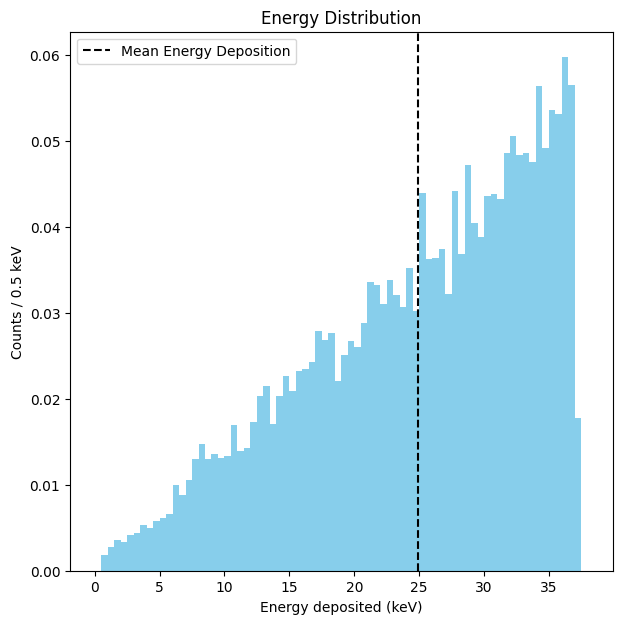

mean energy deposited: 24.917703235605373


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

energy_threshold_keV = 0

N=1000000
square_length = 300 #in cm
sphere_centre = np.array([0,0,-15]) #in cm
sphere_radius = 15 #in cm

x0 = np.zeros(N)
y0 = np.zeros(N)
z0 = np.zeros(N)
theta = np.zeros(N)
phi = np.zeros(N)
dx = np.zeros(N)
dy = np.zeros(N)
dz = np.zeros(N)
b = np.zeros(N)
chord = np.zeros(N)
energy_dep_keV = np.zeros(N)
pressure_bar = 0.5 #in bars
pressure_pa = pressure_bar*(1e5)
room_temp = 293 #in Kelvin
#gas_A = 28 #for N_2
#dEdx_mass = 1.825 #MeV/gcm^2
gas_A = 39.52 #for argon methane
dEdx_mass = 1.526 #MeV/gcm^2
density = (pressure_pa*gas_A)/(8.31*room_temp) / (1e6)
dEdx = dEdx_mass * density * 1000 #in keV/cm


for muon in range(N):
    x0[muon] = np.random.uniform(-square_length/2, square_length/2)
    y0[muon] = np.random.uniform(-square_length/2, square_length/2)
    z0[muon] = 0


    #angles
    accepted = False
    while not accepted:
        theta_trial = np.random.uniform(-np.pi/2, np.pi/2)
        n = np.random.uniform(0, 1)

        if n < (2/np.pi) * np.cos(theta_trial)**2:
            theta[muon] = theta_trial
            accepted = True

    phi[muon] = np.random.uniform(0,2*np.pi)
    #theta[muon] = 0
    #directions
    dx[muon] = np.sin(theta[muon])*np.cos(phi[muon])
    dy[muon] = np.sin(theta[muon])*np.sin(phi[muon])
    dz[muon] = -np.cos(theta[muon])


    #origins = (x0,y0,z0=0) = O
    #directions = (dx,dy,dz) = D
    #sphere centre = (0,0,-d) 
    O = np.array([x0[muon], y0[muon], z0[muon]])
    D = np.array([dx[muon], dy[muon], dz[muon]])
    O_C = O - sphere_centre

    b[muon] = np.linalg.norm(np.cross(O_C, D))

    chord[muon] = 0

    if b[muon] < sphere_radius:
        chord[muon] = 2*np.sqrt(sphere_radius**2 - b[muon]**2)
    else:
        chord[muon] = 0   

    #multiply dE/dx by length to find dE deposited
    energy_dep_keV[muon] = dEdx * chord[muon]

df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b,
    "energy deposited in sphere": energy_dep_keV
})

bins = np.arange(0, np.max(energy_dep_keV) + 1, 0.5)
plt.figure(figsize=(7,7))
plt.hist(energy_dep_keV[energy_dep_keV>0], bins=bins, color='skyblue', density=True)
plt.xlabel("Energy deposited (keV)")
plt.ylabel("Counts / 0.5 keV")
plt.title("Energy Distribution")
plt.axvline(np.mean(energy_dep_keV[energy_dep_keV > 0]),color='k',linestyle='--',label="Mean Energy Deposition")
plt.legend()
plt.show()

mean_energy = np.mean(energy_dep_keV[energy_dep_keV > 0])
print('mean energy deposited:',mean_energy)

#print(df.head())
#print(np.sum(chord > 0))

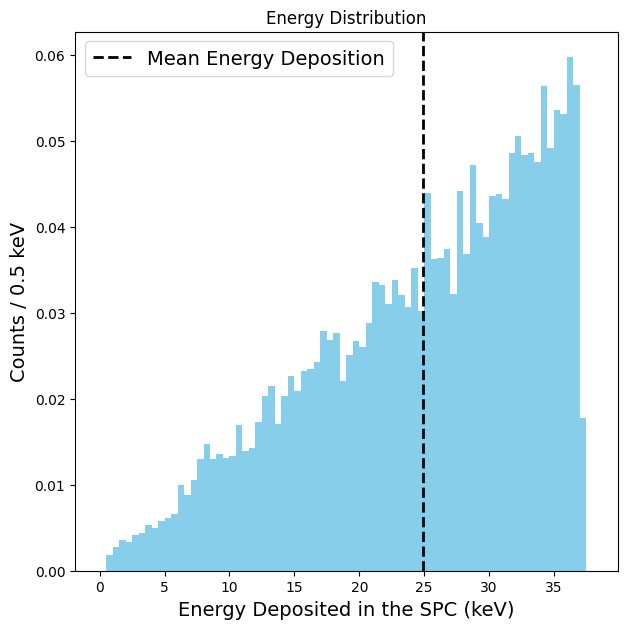

In [12]:
bins = np.arange(0, np.max(energy_dep_keV) + 1, 0.5)
plt.figure(figsize=(7,7))
plt.hist(energy_dep_keV[energy_dep_keV>0], bins=bins, color='skyblue', density=True)
plt.xlabel("Energy Deposited in the SPC (keV)", fontsize=14)
plt.ylabel("Counts / 0.5 keV", fontsize=14)
plt.title("Energy Distribution")
plt.axvline(np.mean(energy_dep_keV[energy_dep_keV > 0]),color='k',linestyle='--', linewidth=2,label="Mean Energy Deposition")
plt.legend(fontsize=14)
plt.show()

In [2]:
#two layer on bottom ALIGNED
scintillator1_pos = np.array([0,0,-90])
scintillator2_pos = np.array([0,0,-97])
scint_width = 25
scint_length = 135
scint_thickness = 1


veto_trigger = np.zeros(N, dtype=bool)
for muon in range(N):
    # intersection with scintillator 1
    t1 = (scintillator1_pos[2] - z0[muon]) / dz[muon]
    x1 = x0[muon] + t1*dx[muon]
    y1 = y0[muon] + t1*dy[muon]

    hit1 = False
    if abs(x1) < scint_width/2 and abs(y1) < scint_length/2:
        hit1 = True

    # intersection with scintillator 2
    t2 = (scintillator2_pos[2] - z0[muon]) / dz[muon]
    x2 = x0[muon] + t2*dx[muon]
    y2 = y0[muon] + t2*dy[muon]

    hit2 = False
    if -scint_width/2 + scintillator2_pos[0]<x2<scint_width/2 + scintillator2_pos[0] and -scint_length/2 + scintillator2_pos[1]<y2<scint_length/2+ scintillator2_pos[1]:
        hit2 = True

    # coincidence
    if hit1 and hit2:
        veto_trigger[muon] = True
        


df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b,
    "energy deposited in sphere": energy_dep_keV,
    "veto trigger": veto_trigger
})

print(df.head())

print('configuration: both below, aligned')
print('total muons in sphere:', np.sum(chord > 0))

veto_and_sphere = (chord > 0) & veto_trigger
print('number passed through veto and sphere:', np.sum(veto_and_sphere))

print('number passed through veto and sphere and sufficient energy:',np.sum(veto_and_sphere & (energy_dep_keV>energy_threshold_keV)))

print('number in veto but not sphere:', np.sum(veto_trigger == True)-np.sum(veto_and_sphere))

       x (cm)      y (cm)  z (cm)  theta (rad)  phi (rad)  chord length (cm)  \
0 -139.378163 -113.586052     0.0    -0.039783   1.173574                0.0   
1   10.710774  -69.925547     0.0     0.219168   2.597149                0.0   
2  129.143207   90.864783     0.0    -0.245456   1.887271                0.0   
3  -57.647056   -7.578934     0.0    -0.250265   0.028517                0.0   
4  100.017292  -85.121277     0.0    -0.533311   1.965409                0.0   

   closest approach to sphere centre  energy deposited in sphere  veto trigger  
0                         180.215869                         0.0         False  
1                          68.034448                         0.0          True  
2                         156.510130                         0.0         False  
3                          60.046482                         0.0         False  
4                         123.710855                         0.0         False  
configuration: both below, aligne

In [3]:
#percentage of muons in sphere which were vetoed
print('Percentage of muons in sphere and veto (no energy consideration):', 100*np.sum(veto_and_sphere)/ np.sum(chord > 0))
print('Percentage of muons in sphere vetoed successfully:', 100* np.sum(veto_and_sphere & (energy_dep_keV>energy_threshold_keV))/ np.sum(chord > 0))

Percentage of muons in sphere and veto (no energy consideration): 27.502487562189053
Percentage of muons in sphere vetoed successfully: 27.502487562189053


In [4]:
print(np.max(energy_dep_keV))

37.15210344244257


In [5]:
#for the realistic sandwich geometry (aligned)

scintillator1_pos = np.array([0,0,0])
scintillator2_pos = np.array([0,0,-220])
scint_width = 25
scint_length = 135
scint_thickness = 1

veto_trigger = np.zeros(N, dtype=bool)
for muon in range(N):
    # intersection with scintillator 1
    t1 = (scintillator1_pos[2] - z0[muon]) / dz[muon]
    x1 = x0[muon] + t1*dx[muon]
    y1 = y0[muon] + t1*dy[muon]

    hit1 = False
    if abs(x1) < scint_width/2 and abs(y1) < scint_length/2:
        hit1 = True

    # intersection with scintillator 2
    t2 = (scintillator2_pos[2] - z0[muon]) / dz[muon]
    x2 = x0[muon] + t2*dx[muon]
    y2 = y0[muon] + t2*dy[muon]

    hit2 = False
    if abs(x2) < scint_width/2 and abs(y2) < scint_length/2:
        hit2 = True

    # coincidence
    if hit1 and hit2:
        veto_trigger[muon] = True
        

df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b,
    "energy deposited in sphere": energy_dep_keV,
    "veto trigger": veto_trigger
})


print('configuration: sandwich, aligned')
print('total muons in sphere:', np.sum(chord > 0))

veto_and_sphere = (chord > 0) & veto_trigger
print('number passed through veto and sphere:', np.sum(veto_and_sphere))

print('number passed through veto and sphere and sufficient energy:',np.sum(veto_and_sphere & (energy_dep_keV>energy_threshold_keV)))

print('number in veto but not sphere:', np.sum(veto_trigger == True)-np.sum(veto_and_sphere))


configuration: sandwich, aligned
total muons in sphere: 10050
number passed through veto and sphere: 1110
number passed through veto and sphere and sufficient energy: 1110
number in veto but not sphere: 3783
